# Corrective RAG -> Correct -> Knowledge Refinement

A basic RAG pipeline retrieves chunks and hands them straight to the LLM. The problem: a retrieved chunk is rarely *entirely* relevant — it usually mixes a few useful sentences in with surrounding noise (headers, unrelated paragraphs, footnotes). That noise can distract the LLM and increase the chance of a wrong or hedged answer.

Knowledge Refinement: when the retrieved context is correct, refine it before answering.

1. **Retrieve** — fetch the top-k chunks for the question, same as basic RAG.
2. **Decompose** — split each retrieved chunk into individual sentences ("strips").
3. **Filter** — ask the LLM to judge each sentence on its own: does it actually help answer the question?
4. **Recompose** — glue the kept sentences back together into a smaller, cleaner "refined context" (`k_in`).
5. **Generate** — answer using only the refined context, not the raw retrieved chunks.

In [3]:
import logging
import re
from pathlib import Path

from typing import List, TypedDict

import fitz
from pydantic import BaseModel
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

from dotenv import load_dotenv

load_dotenv()

logging.getLogger("google_genai.models").setLevel(logging.ERROR)

## Load Documents

In [4]:
def load_pdf(file_path: str) -> list[Document]:
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"PDF not found at: {file_path}")

    documents = []
    with fitz.open(path) as doc:
        for page_num, page in enumerate(doc):
            text = page.get_text("text")
            if not text.strip():
                continue

            metadata = {"source": str(path), "page": page_num + 1, "total_pages": len(doc)}
            documents.append(Document(page_content=text, metadata=metadata))

    return documents


docs = (
    load_pdf("./documents/book1.pdf") +
    load_pdf("./documents/book2.pdf") +
    load_pdf("./documents/book3.pdf")
)

len(docs)

2112

## Split into Chunks

In [5]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

len(chunks)

6711

## Embeddings & Vector Store

In [6]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vector_store = Chroma.from_documents(chunks, embeddings)

In [7]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

## LLM

In [8]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

## Answer Prompt

In [9]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            f"If the bullets are empty or insufficient, say: 'I donot know anything for this context '",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

## Graph State

In [10]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]    # output of decoomposition ()
    selected_strips: List[str]   # selected strips after filtering
    refined_context: str  #recomposed  internal knowledge (refined knowledge with selected strips)

    answer: str

## Retrieve Node

In [11]:
def retrieve(state: State) -> dict:
    question = state["question"]
    retrieved_docs = retriever.invoke(question)
    return {"docs": retrieved_docs}

## Helper: Decompose into Sentences

In [12]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

## Helper: Filter Strips with the LLM

In [13]:
class KeepOrDrop(BaseModel):
    """Relevance verdict for a single sentence."""

    keep: bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Judge the sentence on its own, using no other context.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

## Refine Node

In [22]:
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "selected_strips": kept,
        "refined_context": refined_context,
    }

## Generate Node

In [15]:
def generate(state: State) -> dict:
    question = state["question"]
    refined_context = state["refined_context"]

    response = (answer_prompt | llm).invoke(
        {"question": question, "refined_context": refined_context}
    )

    return {"answer": response.content}

## Build the Graph

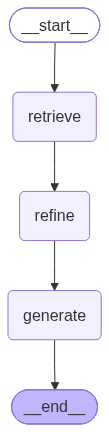

In [16]:
graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("refine", refine)
graph.add_node("generate", generate)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "refine")
graph.add_edge("refine", "generate")
graph.add_edge("generate", END)

app = graph.compile()

app

## Run

In [23]:
question = "Explain the bias-variance tradeoff"

result = app.invoke(
    {
        "question": question,
        "docs": [],
        "strips": [],
        "selected_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("Question:", question)
print()
print("Answer:")
print(result["answer"])

Question: Explain the bias-variance tradeoff

Answer:
The bias-variance trade-off is a frequentist viewpoint of the model complexity issue. Bias and variance measure two different sources of error in an estimator.

*   **Bias** measures the expected deviation from the true value of the function or parameter.
*   **Variance** provides a measure of the deviation from the expected estimator value that any particular sampling of the data is likely to cause.

The trade-off occurs because increasing a model’s complexity will typically increase its variance and reduce its bias. Conversely, reducing a model’s complexity increases its bias and reduces its variance. This involves choosing between estimators, for example, one with more bias and one with more variance, with the goal of trading off bias and variance to minimize Mean Squared Error.

In the context of generalization and overfitting:
*   Underfitting corresponds to inducing bias.
*   Overfitting is the regime where variance rather tha

In [24]:
for index, doc in enumerate(result["docs"], start=1):
    print("Retrieved chunk:", index)
    print(doc.page_content[:400])
    print()

Retrieved chunk: 1
to consider a frequentist viewpoint of the model complexity issue, known as the bias-
variance trade-off. Although we shall introduce this concept in the context of linear
basis function models, where it is easy to illustrate the ideas using simple examples,
the discussion has more general applicability.
In Section 1.5.5, when we discussed decision theory for regression problems,
we considered var

Retrieved chunk: 2
5.4.5
5.4.4
Trading oﬀBias and Variance to Minimize Mean Squared
Error
Bias and variance measure two diﬀerent sources of error in an estimator. Bias
measures the expected deviation from the true value of the function or parameter.
Variance on the other hand, provides a measure of the deviation from the expected
estimator value that any particular sampling of the data is likely to cause.
What happe

Retrieved chunk: 3
Irreducible error
This part is due to the noisiness of the data itself. The only way to reduce this
part of the error is to clean up the da

In [25]:
strip_count = len(result["strips"])
kept_count = len(result["selected_strips"])

print("Sentences decomposed:", strip_count)
print("Sentences kept:", kept_count)
print("Sentences dropped:", strip_count - kept_count)
print()
print("Refined context:")
print(result["refined_context"])

Sentences decomposed: 23
Sentences kept: 0
Sentences dropped: 23

Refined context:
to consider a frequentist viewpoint of the model complexity issue, known as the bias- variance trade-off.
A popular choice is 5.4.5 5.4.4 Trading oﬀBias and Variance to Minimize Mean Squared Error Bias and variance measure two diﬀerent sources of error in an estimator.
Bias measures the expected deviation from the true value of the function or parameter.
Variance on the other hand, provides a measure of the deviation from the expected estimator value that any particular sampling of the data is likely to cause.
What happens when we are given a choice between two estimators, one with more bias and one with more variance?
For example, imagine that we are interested in approximating the function shown in ﬁgure and we are only oﬀered the choice between a model with large bias and 5.2 one that suﬀers from large variance.
Increasing a model’s complexity will typically increase its variance and reduce its bias.
